In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우
# plt.rcParams['font.family'] = 'AppleGothic'  # 맥OS
plt.rcParams['axes.unicode_minus'] = False


In [ ]:
# 1. 데이터 불러오기


# 교통사고
df_acc_raw = pd.read_csv(
    r'C:\Users\82108\Downloads\교통사고+현황(연령층별+사상자)_20260506163932.csv',
    encoding='utf-8-sig'
)
df_acc = df_acc_raw.iloc[2:].copy()
df_acc.columns = ['광역','자치구','항목','합계','12세이하','13~20세','21~30세',
                  '31~40세','41~50세','51~60세','61~64세','65~70세','71세이상','기타']
for col in ['광역','자치구','항목']:
    df_acc[col] = df_acc[col].astype(str).str.strip()

df_acc_injury = df_acc[
    df_acc['항목'].str.contains('부상', na=False) &
    (df_acc['자치구'] != '소계')
].copy()
df_acc_injury['65~70세'] = pd.to_numeric(df_acc_injury['65~70세'], errors='coerce').fillna(0)
df_acc_injury['71세이상'] = pd.to_numeric(df_acc_injury['71세이상'], errors='coerce').fillna(0)
df_acc_injury['노인부상자수'] = df_acc_injury['65~70세'] + df_acc_injury['71세이상']
df_acc_gu = df_acc_injury[['자치구','노인부상자수']].reset_index(drop=True)

print('교통사고 데이터:', df_acc_gu.shape)

교통사고 데이터: (25, 2)


In [ ]:
# 횡단보도 (자치구 단위)

df_cross = pd.read_csv(
    r'C:\Users\82108\Downloads\서울시 자치구 횡단보도 정보 (1).csv',
    encoding='cp949'
)
df_cross.columns = df_cross.columns.str.strip()

cross_gu = df_cross.groupby('시군구명').agg(
    횡단보도수=('연번','count'),
    음향신호기_설치율=('음향신호기설치여부', lambda x: (x=='Y').sum()/len(x)),
    고원식_설치율=('고원식횡단보도유무', lambda x: (x=='Y').sum()/len(x)),
    보행등_설치율=('보행등유무', lambda x: (x=='Y').sum()/len(x))
).reset_index().rename(columns={'시군구명':'자치구'})


In [ ]:
# 전통시장 (자치구 단위)

df_mkt = pd.read_excel(
    r'C:\Users\82108\Downloads\서울시 전통시장 현황(2025.7.31.기준).xlsx'
)
df_mkt.columns = df_mkt.columns.str.strip()
df_mkt = df_mkt.rename(columns={'자치구 ':'자치구','시장명 ':'시장명'})
df_mkt = df_mkt[~df_mkt['연번'].astype(str).isin(['총계','소계','nan'])].copy()
df_mkt = df_mkt[~df_mkt['시장명'].astype(str).str.contains('지하도상점가|지하쇼핑', na=False)].copy()
df_mkt['점포수'] = pd.to_numeric(df_mkt['점포수'], errors='coerce').fillna(0)
mkt_gu = df_mkt.groupby('자치구').agg(
    시장수=('시장명','count'),
    총점포수=('점포수','sum')
).reset_index()

In [ ]:
# 낮시간 유동인구 (자치구 단위)

df_pop = pd.read_csv(
    r'C:\Users\82108\Downloads\도로구간별 추정 유동인구.csv',
    encoding='cp949'
)
df_pop.columns = df_pop.columns.str.strip()

pop_gu = df_pop[
    (df_pop['연령대코드(AGRDE_CD)'] == 60) &
    (df_pop['시간대코드(TMZON_CD)'].isin([2, 3, 4]))
].groupby('시군구명(SIGNGU_NM)').agg(
    노인유동인구_낮평균=('유동인구_수(FLPOP_CO)','mean')
).reset_index().rename(columns={'시군구명(SIGNGU_NM)':'자치구'})


In [ ]:
# 자치구 전체 머지

gu_df = (df_acc_gu
         .merge(cross_gu, on='자치구', how='left')
         .merge(mkt_gu,   on='자치구', how='left')
         .merge(pop_gu,   on='자치구', how='left')
         .fillna(0))

print('자치구 최종 데이터:', gu_df.shape)


자치구 최종 데이터: (25, 9)



R²: 0.7484
RMSE: 46.2260

=== 회귀계수 ===
        변수   표준화_beta
     횡단보도수  77.995255
       시장수  29.597975
   보행등_설치율  26.246366
노인유동인구_낮평균  15.220906
   고원식_설치율  11.642864
      총점포수 -20.617587
 음향신호기_설치율 -23.631235


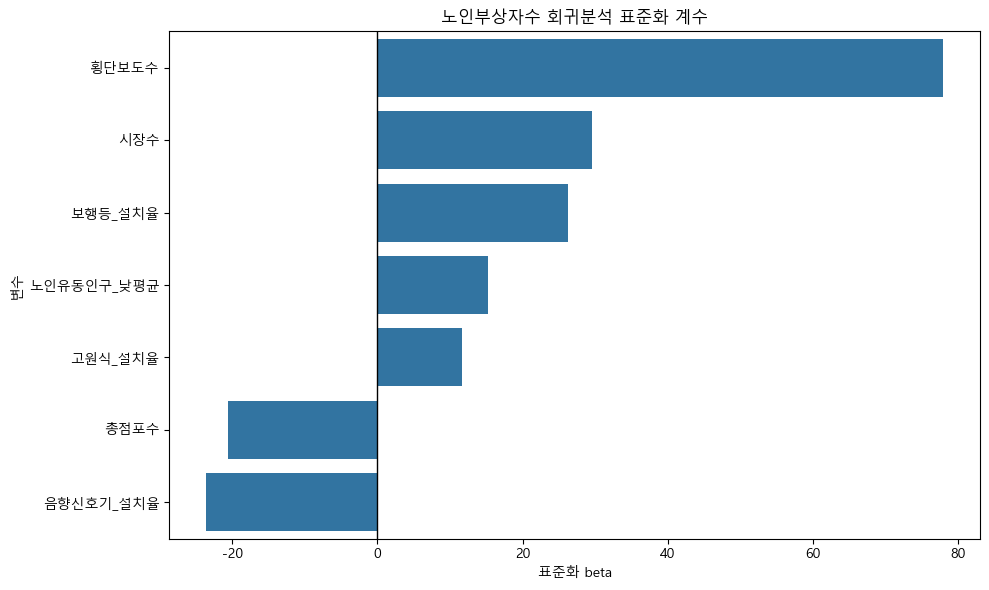

In [ ]:
# 2. 회귀분석 + 가중치 산출

reg_features = [
    '횡단보도수', '음향신호기_설치율', '고원식_설치율',
    '보행등_설치율', '시장수', '총점포수', '노인유동인구_낮평균'
]

scaler_reg = StandardScaler()
X_scaled = scaler_reg.fit_transform(gu_df[reg_features])
y = gu_df['노인부상자수']

reg = LinearRegression()
reg.fit(X_scaled, y)

y_pred = reg.predict(X_scaled)
r2   = r2_score(y, y_pred)
rmse = mean_squared_error(y, y_pred) ** 0.5

coef_df = pd.DataFrame({
    '변수': reg_features,
    '표준화_beta': reg.coef_
}).sort_values('표준화_beta', ascending=False)

print(f'\nR²: {r2:.4f}')
print(f'RMSE: {rmse:.4f}')
print()
print('=== 회귀계수 ===')
print(coef_df.to_string(index=False))

# 회귀계수 시각화
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df, x='표준화_beta', y='변수')
plt.axvline(0, color='black', linewidth=1)
plt.title('노인부상자수 회귀분석 표준화 계수')
plt.xlabel('표준화 beta')
plt.tight_layout()
plt.show()


In [ ]:
# 3. 그룹별 가중치 산출

def make_group_weights(coef_df, group_vars):
    temp = coef_df[coef_df['변수'].isin(group_vars)].copy()
    temp['abs_beta'] = temp['표준화_beta'].abs()
    if temp['abs_beta'].sum() == 0:
        temp['가중치'] = 1 / len(temp)
    else:
        temp['가중치'] = temp['abs_beta'] / temp['abs_beta'].sum()
    return temp[['변수','표준화_beta','가중치']].sort_values('가중치', ascending=False)

risk_vars      = ['노인유동인구_낮평균']
collision_vars = ['횡단보도수','시장수','총점포수']
infra_vars     = ['음향신호기_설치율','고원식_설치율','보행등_설치율']

risk_weights      = make_group_weights(coef_df, risk_vars)
collision_weights = make_group_weights(coef_df, collision_vars)
infra_weights     = make_group_weights(coef_df, infra_vars)

print('\n사고위험 가중치')
print(risk_weights.to_string(index=False))
print('\n보행충돌노출 가중치')
print(collision_weights.to_string(index=False))
print('\n안전인프라 가중치')
print(infra_weights.to_string(index=False))



사고위험 가중치
        변수  표준화_beta  가중치
노인유동인구_낮평균 15.220906  1.0

보행충돌노출 가중치
   변수   표준화_beta      가중치
횡단보도수  77.995255 0.608336
  시장수  29.597975 0.230854
 총점포수 -20.617587 0.160810

안전인프라 가중치
       변수   표준화_beta      가중치
  보행등_설치율  26.246366 0.426628
음향신호기_설치율 -23.631235 0.384120
  고원식_설치율  11.642864 0.189252



=== 자치구 사각지대 TOP 10 ===
 최종개선우선순위  자치구  노인부상자수  사고위험점수_beta  보행충돌노출점수_beta  안전인프라점수_beta  사각지대점수_최종
        1   중구     188     0.077442       0.572307      0.038232      100.0
        2  강남구     494     0.400000       0.644034      0.318241       52.2
        3  중랑구     305     0.736037       0.341972      0.405336       44.3
        4  송파구     427     0.928533       0.499177      0.885556       29.5
        5 영등포구     356     0.259302       0.598884      0.495581       29.3
        6  서초구     308     0.201600       0.452811      0.368532       28.4
        7  성북구     290     0.189522       0.360677      0.417301       21.2
        8  구로구     294     0.186794       0.351605      0.449722       19.3
        9  마포구     182     0.076771       0.440398      0.478082       17.5
       10 동대문구     360     0.257067       0.326562      0.595531       16.3


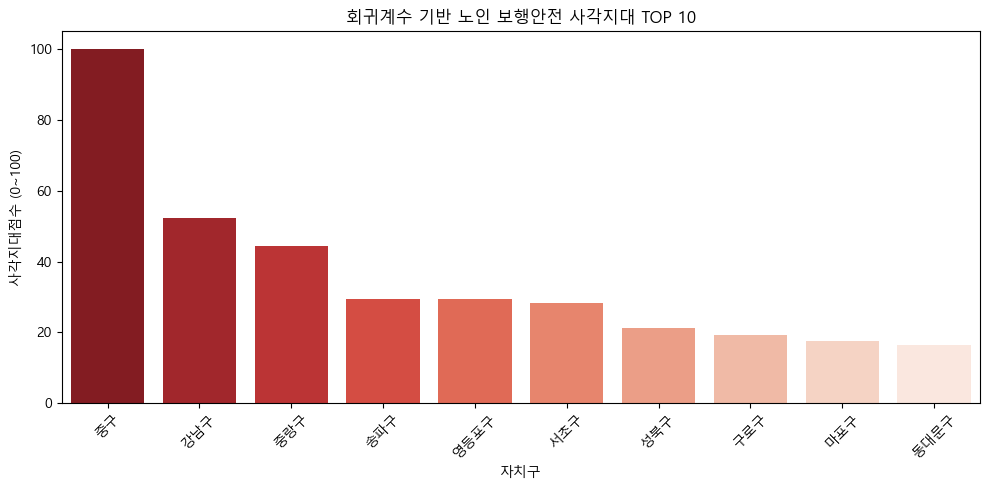

In [ ]:
# 4. 자치구 사각지대 점수 산출

score_vars = list(set(
    risk_vars + collision_vars + infra_vars + ['노인부상자수']
))

scaler_score = MinMaxScaler()
gu_df[[v + '_scaled' for v in score_vars]] = scaler_score.fit_transform(gu_df[score_vars])

def weighted_score(df, weight_df):
    score = 0
    for _, row in weight_df.iterrows():
        var = row['변수']
        w   = row['가중치']
        score += w * df[var + '_scaled']
    return score

gu_df['사고위험요인점수_beta'] = weighted_score(gu_df, risk_weights)
gu_df['사고위험점수_beta'] = (
    0.40 * gu_df['노인부상자수_scaled'] +
    0.60 * gu_df['사고위험요인점수_beta']
)
gu_df['보행충돌노출점수_beta'] = weighted_score(gu_df, collision_weights)
gu_df['안전인프라점수_beta']   = weighted_score(gu_df, infra_weights)
gu_df['사각지대점수_beta'] = (
    gu_df['사고위험점수_beta'] + gu_df['보행충돌노출점수_beta']
) / (gu_df['안전인프라점수_beta'] + 0.1)

# 0~100 정규화
mms_gu = MinMaxScaler(feature_range=(0, 100))
gu_df['사각지대점수_최종'] = mms_gu.fit_transform(
    gu_df[['사각지대점수_beta']]
).round(1)

gu_df['최종개선우선순위'] = gu_df['사각지대점수_최종'].rank(
    ascending=False, method='dense'
).astype(int)

final_priority = gu_df.sort_values('최종개선우선순위').reset_index(drop=True)
top10_gu = final_priority.head(10)['자치구'].tolist()

print('\n=== 자치구 사각지대 TOP 10 ===')
print(final_priority[['최종개선우선순위','자치구','노인부상자수',
                       '사고위험점수_beta','보행충돌노출점수_beta',
                       '안전인프라점수_beta','사각지대점수_최종']].head(10).to_string(index=False))

# 자치구 TOP 10 시각화
top10_final = final_priority.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_final, x='자치구', y='사각지대점수_최종', palette='Reds_r')
plt.title('회귀계수 기반 노인 보행안전 사각지대 TOP 10')
plt.xlabel('자치구')
plt.ylabel('사각지대점수 (0~100)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# 5. 행정동 단위 드릴다운


# 횡단보도 행정동 집계
def extract_dong_cross(addr):
    if pd.isna(addr): return None
    addr = str(addr).strip()
    m = re.match(r'(\S+구)\s+(\S+[동가리](?:\d+가)?)', addr)
    if m: return m.group(1)+' '+m.group(2)
    m2 = re.match(r'(\S+구)\s+(\S+)', addr)
    if m2: return m2.group(1)+' '+m2.group(2)
    return None

df_cross['행정동'] = df_cross['소재지지번주소'].apply(extract_dong_cross)
df_cross['고원식']   = (df_cross['고원식횡단보도유무'] == 'Y').astype(int)
df_cross['음향신호기'] = (df_cross['음향신호기설치여부'] == 'Y').astype(int)
df_cross['보행등']   = (df_cross['보행등유무'] == 'Y').astype(int)

cross_dong = df_cross.dropna(subset=['행정동']).groupby('행정동').agg(
    횡단보도수=('연번','count'),
    고원식횡단보도개수=('고원식','sum'),
    음향신호기개수=('음향신호기','sum'),
    보행등개수=('보행등','sum'),
).reset_index()
cross_dong['고원식_설치율']    = cross_dong['고원식횡단보도개수'] / cross_dong['횡단보도수']
cross_dong['음향신호기_설치율'] = cross_dong['음향신호기개수'] / cross_dong['횡단보도수']
cross_dong['보행등_설치율']    = cross_dong['보행등개수'] / cross_dong['횡단보도수']

# 전통시장 행정동 집계
def extract_dong_mkt(addr, gu=None):
    if pd.isna(addr) or str(addr).strip() in ['0','']: return None
    addr = re.sub(r'^서울특별시\s+','',str(addr).strip())
    addr = re.sub(r'^서울시\s+','',addr)
    addr = re.sub(r'^서울\s+','',addr)
    m = re.search(r'(\S+구)\s+(\S*(?:동\d*가?|\d+가))',addr)
    if m: return m.group(1)+' '+m.group(2)
    m2 = re.search(r'(\S+구)\s+(\S+[동가])',addr)
    if m2: return m2.group(1)+' '+m2.group(2)
    m3 = re.search(r'^(\S*(?:동\d*가?|\d+가))',addr)
    if m3 and gu: return str(gu).strip()+' '+m3.group(1)
    m4 = re.search(r'^(\S+[동가])',addr)
    if m4 and gu: return str(gu).strip()+' '+m4.group(1)
    return None

df_mkt['행정동'] = df_mkt.apply(
    lambda r: extract_dong_mkt(r['구주소(번지주소)'], r['자치구']), axis=1)

manual_map = {
    '강서구 화곡본동시장':'강서구 화곡동',
    '성동구 송정벚꽃골목형상점가':'성동구 송정동',
    '동대문구 장한평역  먹자 골목형상점가':'동대문구 답십리동',
    '중랑구 상봉먹자 골목형상점가':'중랑구 상봉동',
    '중랑구 태능 골목형상점가':'중랑구 상봉동',
    '성북구 월곡달빛오거리골목형상점가':'성북구 월곡동',
    '성북구 정릉시장':'성북구 정릉동',
    '구로구 개봉중앙 골목형상점가':'구로구 개봉동',
    '구로구 극동종합상가 골목형상점가':'구로구 구로동',
    '구로구 오류골먹자골목 골목형상점가':'구로구 오류동',
    '동작구 흑석시장 골목형상점가':'동작구 흑석동',
    '관악구 남현동 예술인마을 골목형상점가':'관악구 남현동',
    '강남구 도곡시장':'강남구 도곡동',
    '송파구 가락몰 골목형상점가':'송파구 가락동',
}
for idx, row in df_mkt[df_mkt['행정동'].isna()].iterrows():
    key = row['자치구']+' '+str(row['시장명']).strip()
    if key in manual_map:
        df_mkt.at[idx, '행정동'] = manual_map[key]

mkt_dong = df_mkt.dropna(subset=['행정동']).groupby('행정동').agg(
    시장수=('시장명','count'),
    총점포수=('점포수','sum')
).reset_index()

# 행정동 머지
dong_df = cross_dong.merge(mkt_dong, on='행정동', how='left')
dong_df['시장수']   = dong_df['시장수'].fillna(0)
dong_df['총점포수'] = dong_df['총점포수'].fillna(0)
dong_df['자치구']   = dong_df['행정동'].str.extract(r'^(\S+구)')

# TOP 10 자치구만 필터링
dong_df = dong_df[dong_df['자치구'].isin(top10_gu)].copy()

# 안전시설 부족도
dong_df['음향신호기_부족도'] = 1 - dong_df['음향신호기_설치율']
dong_df['고원식_부족도']   = 1 - dong_df['고원식_설치율']
dong_df['보행등_부족도']   = 1 - dong_df['보행등_설치율']

# 행정동 점수 계산
dong_score_cols = ['횡단보도수','시장수','총점포수',
                   '음향신호기_부족도','고원식_부족도','보행등_부족도']

scaler_dong = MinMaxScaler()
dong_df[[col+'_scaled' for col in dong_score_cols]] = scaler_dong.fit_transform(
    dong_df[dong_score_cols]
)

dong_df['행정동_개선후보점수'] = (
    0.35 * dong_df['횡단보도수_scaled'] +
    0.20 * dong_df['시장수_scaled'] +
    0.15 * dong_df['총점포수_scaled'] +
    0.10 * dong_df['음향신호기_부족도_scaled'] +
    0.10 * dong_df['고원식_부족도_scaled'] +
    0.10 * dong_df['보행등_부족도_scaled']
)



=== 자치구별 위험 행정동 TOP 3 ===
 자치구       행정동  횡단보도수  시장수   총점포수  음향신호기_설치율  고원식_설치율  보행등_설치율  행정동_개선후보점수_정규화
 강남구   강남구 역삼동    369  2.0  246.0   0.241192 0.021680 0.271003            55.4
 강남구   강남구 대치동    372  1.0  549.0   0.241935 0.029570 0.255376            54.5
 강남구   강남구 논현동    286  2.0  180.0   0.143357 0.010490 0.167832            53.1
 구로구   구로구 구로동    650  3.0  393.0   0.287692 0.032308 0.327692            77.1
 구로구   구로구 고척동    256  5.0  458.0   0.230469 0.035156 0.269531            52.6
 구로구   구로구 개봉동    233  3.0  115.0   0.145923 0.034335 0.210300            48.9
동대문구  동대문구 제기동    130  9.0 2352.0   0.392308 0.030769 0.407692            50.1
동대문구  동대문구 장안동    257  3.0  258.0   0.194553 0.093385 0.280156            46.5
동대문구 동대문구 답십리동    206  5.0  374.0   0.315534 0.121359 0.398058            40.9
 마포구   마포구 상암동    275  1.0  175.0   0.309091 0.010909 0.414545            42.3
 마포구   마포구 망원동    169  3.0  215.0   0.224852 0.047337 0.242604            41.5
 마포구   마포구 공덕동    131  2.

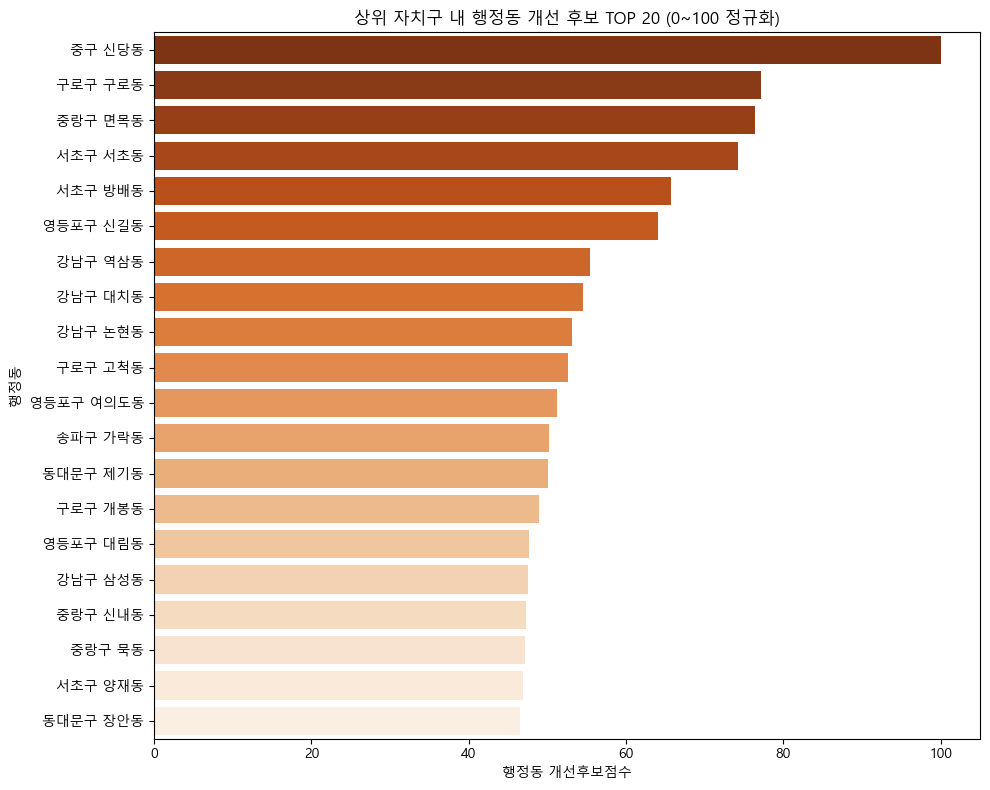

In [ ]:
# 6. 행정동 점수 0~100 정규화

mms_dong = MinMaxScaler(feature_range=(0, 100))
dong_df['행정동_개선후보점수_정규화'] = mms_dong.fit_transform(
    dong_df[['행정동_개선후보점수']]
).round(1)

dong_priority = dong_df.sort_values(
    ['자치구','행정동_개선후보점수_정규화'], ascending=[True, False]
)

# 자치구별 TOP 3 행정동
dong_top3_by_gu = (
    dong_priority
    .groupby('자치구')
    .head(3)
    [['자치구','행정동','횡단보도수','시장수','총점포수',
      '음향신호기_설치율','고원식_설치율','보행등_설치율',
      '행정동_개선후보점수_정규화']]
)

print('\n=== 자치구별 위험 행정동 TOP 3 ===')
print(dong_top3_by_gu.to_string(index=False))

# 전체 TOP 20
dong_top20 = dong_df.sort_values('행정동_개선후보점수_정규화', ascending=False).head(20)

print('\n=== 위험 행정동 TOP 20 (정규화 점수) ===')
print(dong_top20[['행정동','자치구','횡단보도수','시장수',
                   '음향신호기_설치율','행정동_개선후보점수_정규화']].to_string(index=False))

# 행정동 TOP 20 시각화
plt.figure(figsize=(10, 8))
sns.barplot(data=dong_top20, x='행정동_개선후보점수_정규화', y='행정동', palette='Oranges_r')
plt.title('상위 자치구 내 행정동 개선 후보 TOP 20 (0~100 정규화)')
plt.xlabel('행정동 개선후보점수')
plt.tight_layout()
plt.show()


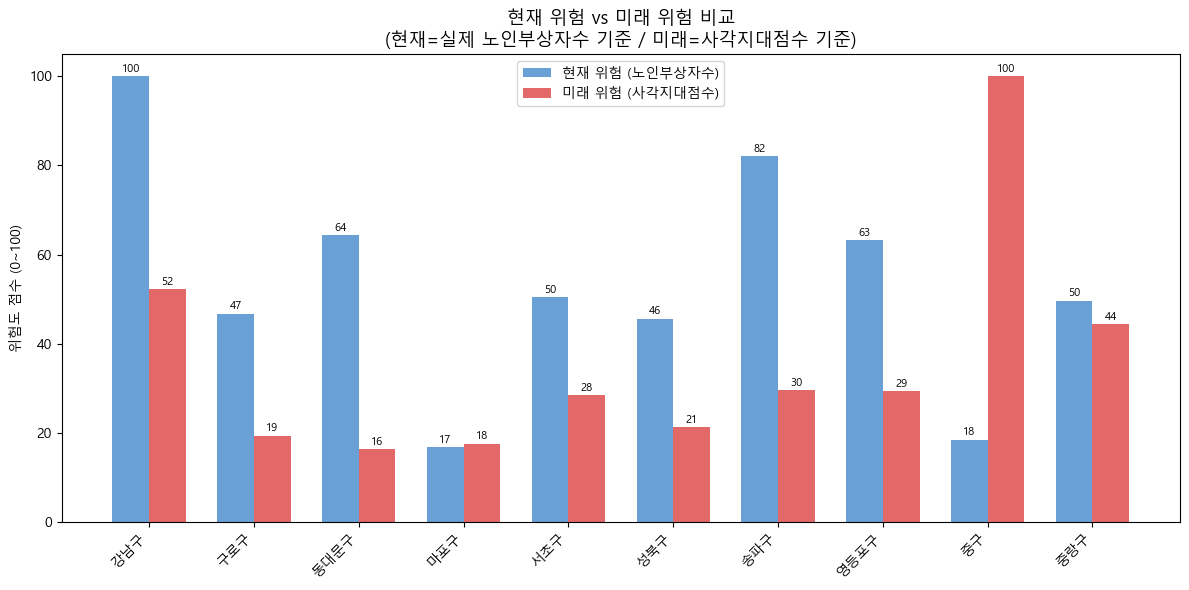

In [ ]:
# 추가 시각화 1 — 현재 위험 vs 미래 위험 비교


# 현재 위험: 노인부상자수 순위
# 미래 위험: 사각지대점수 순위
compare_df = final_priority[['자치구','노인부상자수','사각지대점수_최종']].copy()

# 각각 정규화 0~100
mms_compare = MinMaxScaler(feature_range=(0, 100))
compare_df['현재위험_정규화'] = mms_compare.fit_transform(
    compare_df[['노인부상자수']]).round(1)
compare_df['미래위험_정규화'] = compare_df['사각지대점수_최종']

# TOP 10만
compare_top10 = compare_df.head(10).sort_values('자치구')

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(compare_top10))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x],
               compare_top10['현재위험_정규화'],
               width, label='현재 위험 (노인부상자수)', color='#4488CC', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x],
               compare_top10['미래위험_정규화'],
               width, label='미래 위험 (사각지대점수)', color='#DD4444', alpha=0.8)

ax.set_xticks(list(x))
ax.set_xticklabels(compare_top10['자치구'], rotation=45, ha='right')
ax.set_ylabel('위험도 점수 (0~100)')
ax.set_title('현재 위험 vs 미래 위험 비교\n(현재=실제 노인부상자수 기준 / 미래=사각지대점수 기준)',
             fontsize=13)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.0f}', ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{bar.get_height():.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('현재vs미래_위험비교.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
현재 위험 vs 미래 위험 비교 그래프
실제 노인 부상자수(현재 위험)와 회귀분석 기반 사각지대점수(미래 위험)를 자치구별로 나란히 비교한 그래프
두 지표의 순위 차이가 클수록 현재는 사고가 적더라도 앞으로 위험해질 가능성이 높은 지역

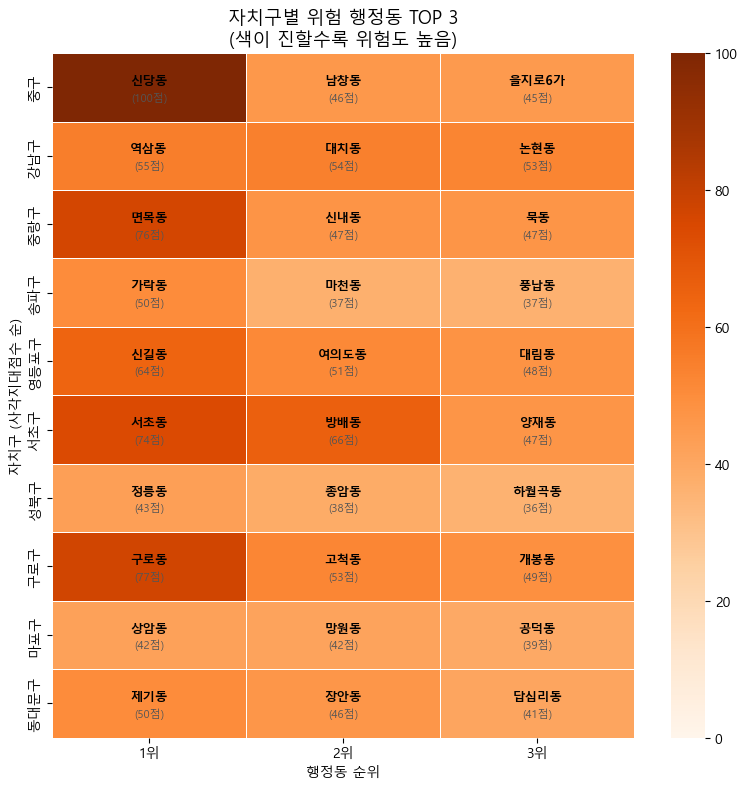

In [ ]:
# 추가 시각화 2 — 자치구별 TOP 3 행정동 히트맵

# 자치구별 TOP 3 행정동 피벗
dong_top3_pivot = (
    dong_priority
    .groupby('자치구')
    .head(3)
    .copy()
)
dong_top3_pivot['순위'] = dong_top3_pivot.groupby('자치구').cumcount() + 1
dong_top3_pivot['순위'] = dong_top3_pivot['순위'].map({1:'1위', 2:'2위', 3:'3위'})

pivot_table = dong_top3_pivot.pivot(
    index='자치구',
    columns='순위',
    values='행정동_개선후보점수_정규화'
).fillna(0)

# 자치구 순서를 사각지대점수 순으로
gu_order = final_priority.head(10)['자치구'].tolist()
pivot_table = pivot_table.reindex(gu_order)

# 히트맵
fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(
    pivot_table,
    annot=False,
    cmap='Oranges',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=100
)

# 셀 안에 행정동 이름 표시
for i, gu in enumerate(pivot_table.index):
    for j, rank in enumerate(pivot_table.columns):
        dong_name = dong_top3_pivot[
            (dong_top3_pivot['자치구'] == gu) &
            (dong_top3_pivot['순위'] == rank)
        ]['행정동'].values
        score = pivot_table.loc[gu, rank]
        if len(dong_name) > 0:
            dong_label = dong_name[0].replace(gu+' ', '')
            ax.text(j+0.5, i+0.4, dong_label,
                    ha='center', va='center', fontsize=9, fontweight='bold')
            ax.text(j+0.5, i+0.65, f'({score:.0f}점)',
                    ha='center', va='center', fontsize=8, color='#555555')

ax.set_title('자치구별 위험 행정동 TOP 3\n(색이 진할수록 위험도 높음)', fontsize=13)
ax.set_xlabel('행정동 순위')
ax.set_ylabel('자치구 (사각지대점수 순)')
plt.tight_layout()
plt.savefig('자치구별_TOP3_행정동_히트맵.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
자치구별 TOP 3 행정동 히트맵
상위 10개 자치구 안에서 개선이 가장 시급한 행정동을 3개씩 추출한 히트맵
색이 진할수록 위험도가 높으며,행정동명과 정규화 점수가 함께 표시되어 있어 어느 동네에 안전시설을 우선 설치해야 하는지 한눈에 확인할 수 있습니다.